In [1]:
# Cell 1 — Load data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("training_ready.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (78057, 10)


,Temperature,Elevation,Population Density,Energy Consumption,AQI,Urban Greenness Ratio,Wind Speed,Humidity,Annual Rainfall,severity
0,32.140727,1657.234222,638.140184,29866.608120,90.967582,51.032061,0.017909,46.681317,1750.054664,0
1,28.199772,1781.007943,2757.814606,25461.567500,121.919061,17.819991,1.585266,43.291975,758.591768,0
2,11.492930,3140.598901,6020.462986,2539.737270,169.190188,51.045248,8.614523,76.935296,2494.912602,0
3,34.909265,992.282813,9491.952711,32146.724390,90.989624,19.211930,0.297596,42.739059,1762.646698,2
4,28.465786,597.192562,5191.476501,2513.126338,92.082516,51.178231,19.375498,43.509082,2134.723878,0


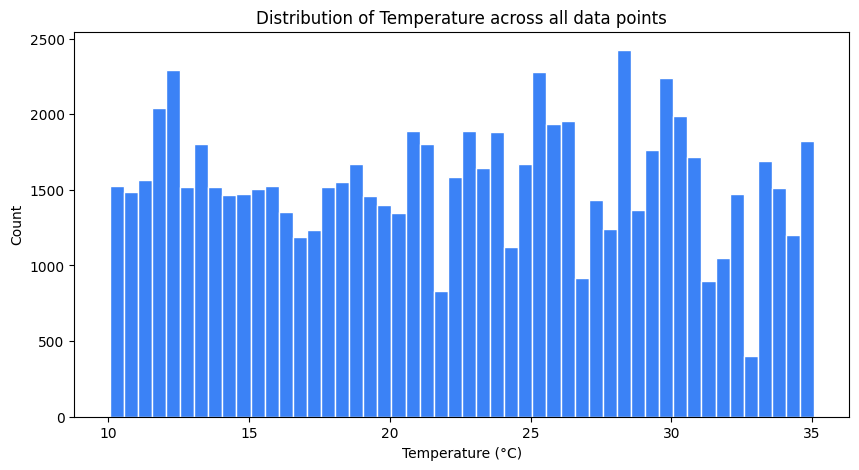

In [2]:
# Cell 2 — UHI intensity distribution
# Cell 2 — Temperature distribution (proxy for UHI)
plt.figure(figsize=(10,5))
plt.hist(df["Temperature"], bins=50, color="#3b82f6", edgecolor="white")

plt.title("Distribution of Temperature across all data points")
plt.xlabel("Temperature (°C)")
plt.ylabel("Count")

plt.savefig("temperature_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

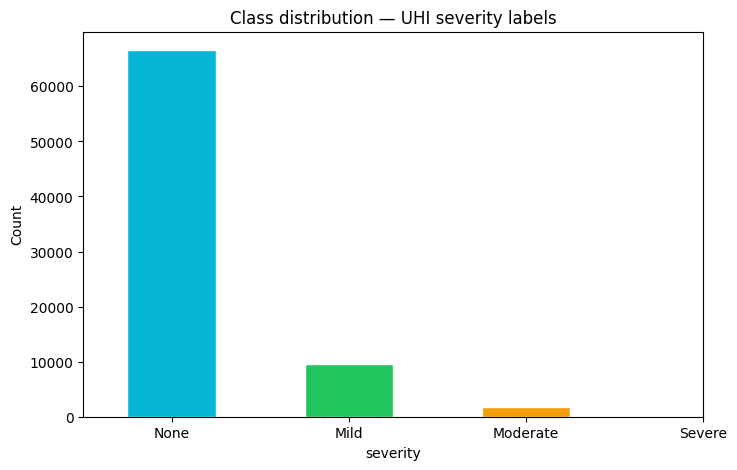

In [3]:
# Cell 3 — Severity class balance
plt.figure(figsize=(8,5))
labels = ["None", "Mild", "Moderate", "Severe"]
colors = ["#06b6d4", "#22c55e", "#f59e0b", "#dc2626"]
df["severity"].value_counts().sort_index().plot(
    kind="bar", color=colors, edgecolor="white"
)
plt.xticks([0,1,2,3], labels, rotation=0)
plt.title("Class distribution — UHI severity labels")
plt.ylabel("Count")
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

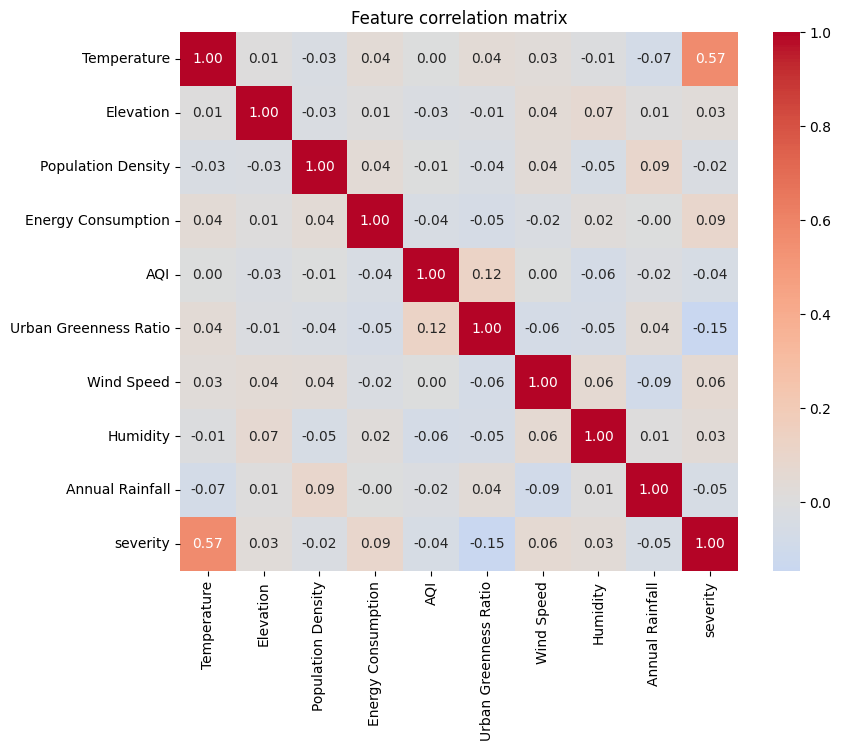

In [4]:
# Cell 4 — Correlation heatmap
plt.figure(figsize=(9,7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation matrix")
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

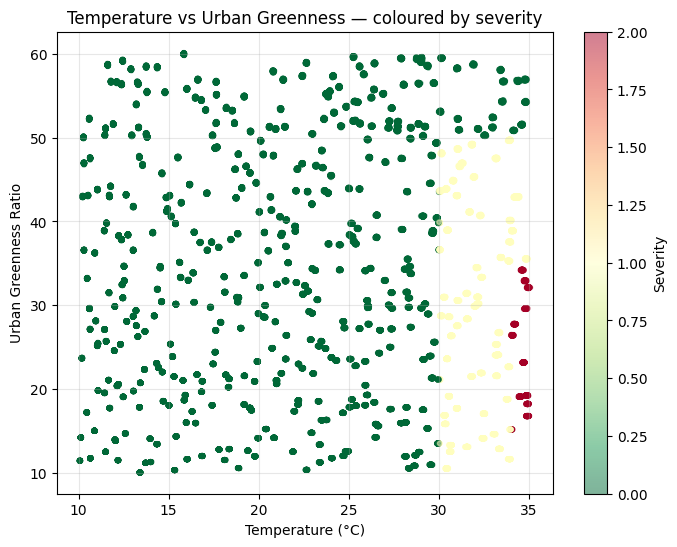

In [5]:
# Cell 5 — Urban vs rural temp scatter
# Cell 5 — Temperature vs Greenness (proxy for urban/rural effect)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    df["Temperature"],
    df["Urban Greenness Ratio"],
    c=df["severity"],
    cmap="RdYlGn_r",
    alpha=0.5,
    s=10
)

plt.colorbar(scatter, label="Severity")

plt.xlabel("Temperature (°C)")
plt.ylabel("Urban Greenness Ratio")
plt.title("Temperature vs Urban Greenness — coloured by severity")

plt.grid(alpha=0.3)

plt.savefig("temp_vs_greenness.png", dpi=150, bbox_inches="tight")
plt.show()